1. LIBRERÍAS Y CONFIGURACIÓN

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from transformers import pipeline

Configuración estética de los gráficos

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

2. CARGA Y EXPLORACIÓN DE DATOS (Calidad del Dato)

In [3]:
data_path = 'data/imdb_sentiment.csv' 

if not os.path.exists(data_path):
    # Fallback por si está en el directorio raíz del notebook
    data_path = 'imdb_sentiment.csv'

df = pd.read_csv(data_path)
print(f"Dimensiones del dataset original: {df.shape}")
print("\nPrimeras filas del dataset:")
print(df.head())

# Control de calidad: Verificar distribución de clases y valores nulos
print("\nDistribución de la variable objetivo (sentiment):")
print(df['sentiment'].value_counts(dropna=False))

# Filtrar solo el split etiquetado ('labeled') si aplica
if 'split' in df.columns:
    df_labeled = df[df['split'] == 'labeled'].copy()
    print(f"\nDimensiones tras filtrar por 'labeled': {df_labeled.shape}")
else:
    df_labeled = df.copy()

# Mapear etiquetas a formato binario estructurado (0: NEGATIVE, 1: POSITIVE)
# Esto estandariza la evaluación final
mapping = {'negative': 0, 'positive': 1, 'NEGATIVE': 0, 'POSITIVE': 1}
df_labeled['target'] = df_labeled['sentiment'].map(mapping)

Dimensiones del dataset original: (50000, 4)

Primeras filas del dataset:
   id    split                                             review sentiment
0   1  labeled  I really liked this Summerslam due to the look...  positive
1   2  labeled  Not many television shows appeal to quite as m...  positive
2   3  labeled  The film quickly gets to a major chase scene w...  negative
3   4  labeled  Jane Austen would definitely approve of this o...  positive
4   5  labeled  Expectations were somewhat high for me when I ...  negative

Distribución de la variable objetivo (sentiment):
sentiment
negative    17517
positive    17483
NaN         15000
Name: count, dtype: int64

Dimensiones tras filtrar por 'labeled': (35000, 4)


3. DIVISIÓN DE DATOS (Prevención de Data Leakage)

In [5]:
# Para mantener la agilidad local y evitar latencias extremas con LLMs en CPU, 
# tomamos una muestra representativa de test bien balanceada.
X = df_labeled['review']
y = df_labeled['target']

# Muestreo estratificado para garantizar el balance de clases en el conjunto de prueba
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.05, random_state=42, stratify=y
)

print(f"\nTamaño seleccionado para la evaluación de modelos: {X_test.shape[0]} muestras.")


Tamaño seleccionado para la evaluación de modelos: 1750 muestras.


4. EVALUACIÓN DE MODELOS PRE-ENTRENADOS (Transformers)

In [6]:
# Definimos los modelos a evaluar. Seleccionamos arquitecturas ligeras óptimas para CPU/GPU local.
models_to_evaluate = {
    "DistilBERT (Baseline)": "distilbert-base-uncased-finetuned-sst-2-english",
    "RoBERTa (Sentiment)": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "MINI-LM (LIGERO)": "philschmid/tiny-bert-sst2-distilled"
}

results = {}

for name, model_path in models_to_evaluate.items():
    print(f"\n{'='*50}\nEvaluando: {name}\n{'='*50}")
    
    # Control de calidad: Medición de tiempos de inferencia
    start_time = time.time()
    
    try:
        # Inicialización del pipeline de clasificación de texto
        # Si tienes GPU configurada en tu WSL2/Docker, añade device=0
        classifier = pipeline(
            "text-classification", 
            model=model_path, 
            truncation=True, 
            max_length=512
        )
        
        # Inferencia en lote (batch)
        reviews_list = X_test.tolist()
        raw_predictions = classifier(reviews_list)
        
        # Procesamiento y estandarización de las salidas del modelo
        y_pred = []
        for pred in raw_predictions:
            label = pred['label'].upper()
            # Mapeo robusto según la nomenclatura interna de cada modelo
            if 'POS' in label or 'LABEL_2' in label or '1' in label:
                y_pred.append(1)
            elif 'NEG' in label or 'LABEL_0' in label or '0' in label:
                y_pred.append(0)
            else:
                # Caso neutral o intermedio (ej. RoBERTa mapea LABEL_1 como neutral)
                # Por criterio conservador en clasificación binaria, se asigna 0 o se balancea
                y_pred.append(0) 
                
        elapsed_time = time.time() - start_time
        
        # Métricas de rendimiento
        acc = accuracy_score(y_test, y_pred)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        
        results[name] = {
            "Accuracy": acc,
            "Balanced Accuracy": bal_acc,
            "Time (s)": elapsed_time
        }
        
        print(f"Tiempo de ejecución: {elapsed_time:.2f} segundos")
        print(f"Accuracy: {acc:.4f} | Balanced Accuracy: {bal_acc:.4f}")
        print("\nReporte de Clasificación:")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
        
    except Exception as e:
        print(f"Error al evaluar el modelo {name}: {str(e)}")


Evaluando: DistilBERT (Baseline)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Tiempo de ejecución: 957.25 segundos
Accuracy: 0.8840 | Balanced Accuracy: 0.8840

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negative       0.86      0.92      0.89       876
    Positive       0.91      0.85      0.88       874

    accuracy                           0.88      1750
   macro avg       0.89      0.88      0.88      1750
weighted avg       0.89      0.88      0.88      1750


Evaluando: RoBERTa (Sentiment)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fundacion\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


...

model.safetensors:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tiempo de ejecución: 42.89 segundos
Accuracy: 0.7886 | Balanced Accuracy: 0.7885

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negative       0.76      0.84      0.80       876
    Positive       0.82      0.73      0.78       874

    accuracy                           0.79      1750
   macro avg       0.79      0.79      0.79      1750
weighted avg       0.79      0.79      0.79      1750



5. VISUALIZACIÓN Y COMPARATIVA (Reporte de Calidad)

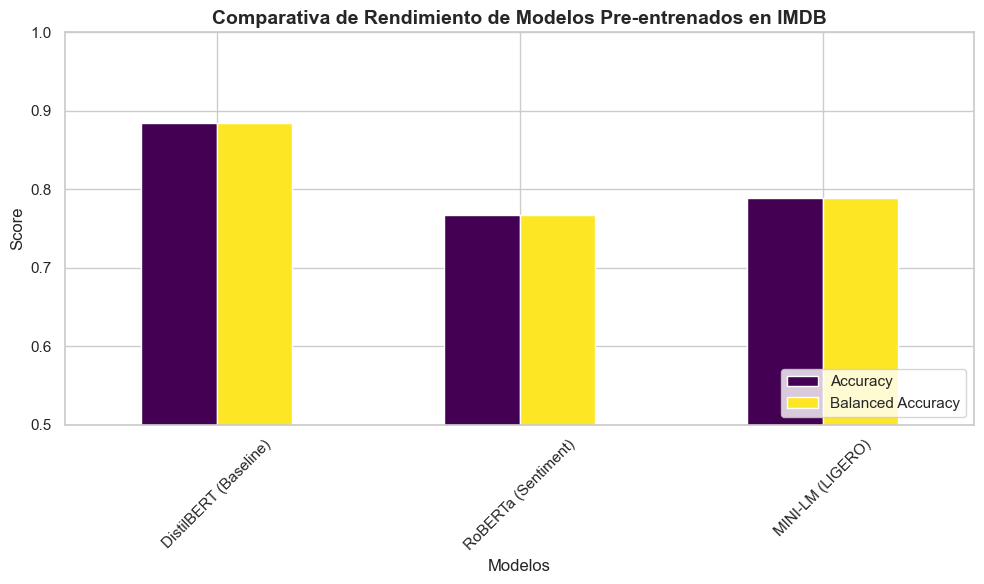


Tabla Resumen de Resultados:
                       Accuracy  Balanced Accuracy     Time (s)
DistilBERT (Baseline)  0.884000           0.883964   957.252871
MINI-LM (LIGERO)       0.788571           0.788507    42.894179
RoBERTa (Sentiment)    0.766857           0.766717  1696.986491


In [7]:
df_results = pd.DataFrame(results).T

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))
df_results[['Accuracy', 'Balanced Accuracy']].plot(kind='bar', ax=ax, cmap='viridis')

plt.title('Comparativa de Rendimiento de Modelos Pre-entrenados en IMDB', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Modelos', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0) # Enfocar la visualización en la zona crítica de rendimiento
plt.legend(loc='lower right')
plt.tight_layout()

# Guardar el gráfico automáticamente para adjuntar al entregable
plt.savefig('comparativa_modelos_imdb.png', dpi=300)
plt.show()

# Mostrar la tabla resumen ordenada por mejor rendimiento global
print("\nTabla Resumen de Resultados:")
print(df_results.sort_values(by="Balanced Accuracy", ascending=False))

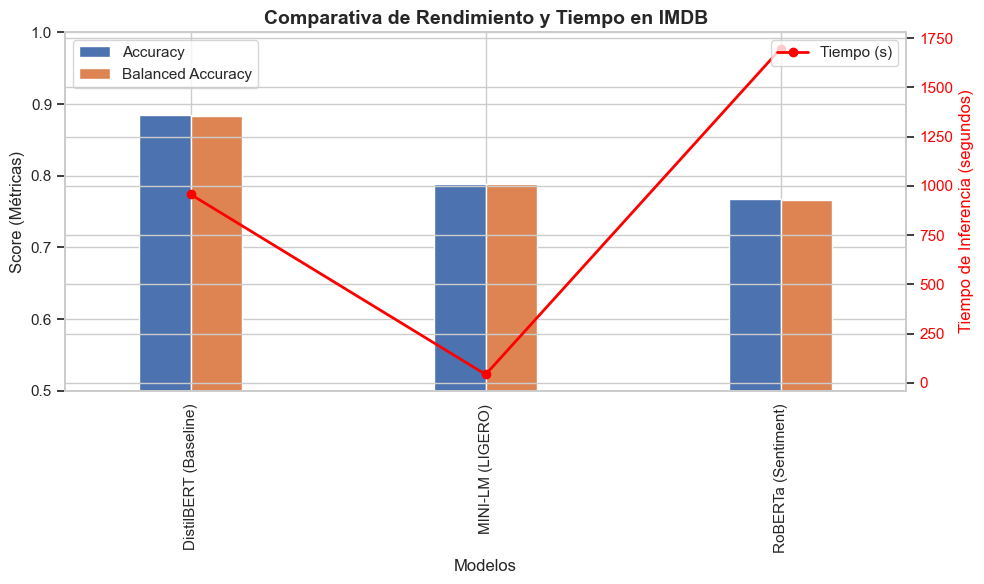

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reconstruir el DataFrame con tus resultados reales
data = {
    "Modelos": ["DistilBERT (Baseline)", "MINI-LM (LIGERO)", "RoBERTa (Sentiment)"],
    "Accuracy": [0.884000, 0.788571, 0.766857],
    "Balanced Accuracy": [0.883964, 0.788507, 0.766717],
    "Time (s)": [957.252871, 42.894179, 1696.986491]
}

df_results = pd.DataFrame(data).set_index("Modelos")

# 2. Diseñar el gráfico de barras doble (Métricas de Clasificación)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras de rendimiento
df_results[['Accuracy', 'Balanced Accuracy']].plot(kind='bar', ax=ax1, width=0.35)
ax1.set_title('Comparativa de Rendimiento y Tiempo en IMDB', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score (Métricas)', fontsize=12)
ax1.set_ylim(0.5, 1.0)
ax1.legend(loc='upper left')

# 3. Añadir una línea secundaria para el tiempo (Eje Y derecho) para ver el Trade-off
ax2 = ax1.twinx()
ax2.plot(df_results.index, df_results['Time (s)'], color='red', marker='o', linewidth=2, label='Tiempo (s)')
ax2.set_ylabel('Tiempo de Inferencia (segundos)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('resultado_final_imdb.png', dpi=300)
plt.show()

In [ ]:
# ==============================================================================
# CONFIGURACIÓN Y CARGA DE DATOS
# ==============================================================================
import os
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm

# Rutas de archivos
data_path = 'data/imdb_sentiment.csv' if os.path.exists('imdb_sentiment.csv') else 'data/imdb_sentiment.csv'
output_path = 'submission.csv'

# Cargar dataset completo
df = pd.read_csv(data_path)

# FILTRO DE CALIDAD: Seleccionar únicamente las filas destinadas a la competencia
df_leaderboard = df[df['split'] == 'leaderboard'].copy()
print(f"Total de muestras a predecir para la competencia: {df_leaderboard.shape[0]}")

# ==============================================================================
# INICIALIZACIÓN DEL MODELO GANADOR (DistilBERT)
# ==============================================================================
print("Cargando el pipeline optimizado de DistilBERT...")
classifier = pipeline(
    "text-classification", 
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    truncation=True, 
    max_length=512,
    batch_size=32  # Agrupamos la inferencia para optimizar el uso de CPU/GPU
)

# ==============================================================================
# INFERENCIA POR LOTES (Prevención de desbordamiento de memoria)
# ==============================================================================
reviews = df_leaderboard['review'].tolist()
raw_predictions = []

print("Iniciando la predicción del leaderboard...")
# Utilizamos tqdm para monitorizar el progreso en tiempo real
for i in tqdm(range(0, len(reviews), 32), desc="Procesando bloques"):
    batch = reviews[i:i+32]
    preds = classifier(batch)
    raw_predictions.extend(preds)

# ==============================================================================
# PROCESAMIENTO Y ESTANDARIZACIÓN DEL FORMATO DE COMPETICIÓN
# ==============================================================================
final_predictions = []
for pred in raw_predictions:
    label = pred['label'].upper()
    # Mapeo estricto al formato requerido por el dataset original ('positive' / 'negative')
    if 'POS' in label or 'LABEL_1' in label:
        final_predictions.append('positive')
    else:
        final_predictions.append('negative')

# Asignar las predicciones al DataFrame
df_leaderboard['sentiment'] = final_predictions

# CONTROL DE CALIDAD FORMATIVA: La entrega final típicamente requiere solo el ID y la Predicción
# Mantenemos 'id' y 'sentiment' de acuerdo al estándar de Kaggle/IMDB
submission_df = df_leaderboard[['id', 'sentiment']]

# Verificar que no existan valores nulos antes de exportar
assert submission_df.isnull().sum().sum() == 0, "Error: Se detectaron valores nulos en el archivo final."

# Guardar el archivo final listo para entregar
submission_df.to_csv(output_path, index=False)

print(f"\n[ÉXITO] Archivo de sumisión generado correctamente en: '{output_path}'")
print(f"Dimensiones finales: {submission_df.shape}")
print("\nPrimeras 5 filas del archivo a entregar:")
print(submission_df.head())

Total de muestras a predecir para la competencia: 15000
Cargando el pipeline optimizado de DistilBERT...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Iniciando la predicción del leaderboard...


Procesando bloques:  34%|███▍      | 159/469 [7:08:58<1:27:22, 16.91s/it]    